# Notebook 4 — Model Evaluation & Error Analysis
Evaluate the performance of the trained RT-DETR pothole detector using quantitative metrics and qualitative analysis. Identify the strengths and limitations of the baseline model and establish a foundation for subsequent optimization experiments.

1. Project Overview
2. Load Experiment Results
3. Evaluation Metrics
4. Loss Curve Analysis
5. Precision-Recall Analysis
6. Confusion Matrix Analysis
7. Validation Prediction Analysis
8. Failure Case Analysis
9. Model Strengths & Weaknesses
10. Conclusion

Unlike the previous notebook, which focused on model training, this notebook analyzes the resulting model from both quantitative and qualitative perspectives.

The evaluation includes:

- Overall detection performance
- Loss convergence analysis
- Precision–Recall analysis
- Confusion matrix interpretation
- Validation prediction visualization
- Failure case analysis
- Strengths and limitations of the baseline model

The findings from this notebook will guide future hyperparameter optimization experiments and model improvements.

# 1. Load Trained Experiment

The best-performing RT-DETR checkpoint and associated experiment artifacts are loaded for evaluation.

These include:

- Training metrics
- Loss curves
- Validation predictions
- Confusion matrix
- Experiment configuration

In [5]:
# ==========================================================
# Load Baseline RT-DETR Experiment
# ==========================================================

from pathlib import Path
import pandas as pd

SAVE_DIR = Path(
    "/kaggle/input/models/krishnatheachiever/baseline-rtdetr-l-2/pytorch/v2/1"
)

assert SAVE_DIR.exists(), "Experiment directory not found."

results_csv = pd.read_csv(SAVE_DIR / "results.csv")

print(f"Experiment Directory : {SAVE_DIR}")
print(f"Epochs Logged        : {len(results_csv)}")
print(f"Available Files      : {len(list(SAVE_DIR.iterdir()))}")

Experiment Directory : /kaggle/input/models/krishnatheachiever/baseline-rtdetr-l-2/pytorch/v2/1
Epochs Logged        : 75
Available Files      : 24


# Experiment Summary

This notebook analyzes the results obtained from the baseline RT-DETR-L training experiment.

Unlike the training notebook, no model training is performed here.

The objectives of this notebook are:

- Load saved experiment artifacts
- Analyze training and validation metrics
- Visualize convergence behavior
- Evaluate detection performance
- Inspect qualitative prediction examples
- Summarize observations for comparison with future experiments

This separation improves reproducibility and follows standard deep learning research workflow.

In [6]:
summary = pd.DataFrame({

"Metric":[

"Model",

"Epochs",

"Image Size",

"Batch Size",

"Precision",

"Recall",

"mAP@50",

"mAP@50-95"

],

"Value":[

"RT-DETR-L",

75,

640,

16,

results_csv.iloc[-1]["metrics/precision(B)"],

results_csv.iloc[-1]["metrics/recall(B)"],

results_csv.iloc[-1]["metrics/mAP50(B)"],

results_csv.iloc[-1]["metrics/mAP50-95(B)"]

]

})

summary

,Metric,Value
0,Model,RT-DETR-L
1,Epochs,75
2,Image Size,640
3,Batch Size,16
4,Precision,0.8912
5,Recall,0.79152
6,mAP@50,0.85366
7,mAP@50-95,0.54064


# 3. Training Curve Analysis

Training and validation losses provide insight into the optimization behavior of the detector.

A well-converged model should exhibit:

- Consistent reduction in losses
- Stable validation losses
- No significant divergence between training and validation trends

These plots help determine whether the model is underfitting, converging appropriately, or overfitting.

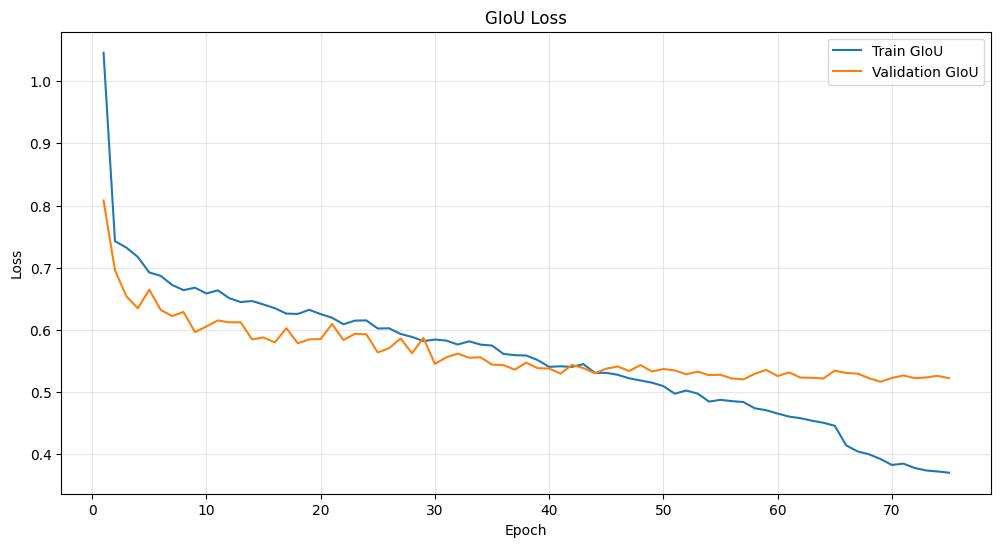

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(results_csv["epoch"],results_csv["train/giou_loss"],label="Train GIoU")

plt.plot(results_csv["epoch"],results_csv["val/giou_loss"],label="Validation GIoU")

plt.legend()

plt.grid(alpha=.3)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("GIoU Loss")

plt.show()

# 4. Detection Performance

The primary evaluation metrics for object detection include:

- Precision
- Recall
- mAP@50
- mAP@50–95

Tracking these metrics across epochs helps determine the stability of the learning process and the overall quality of the detector.

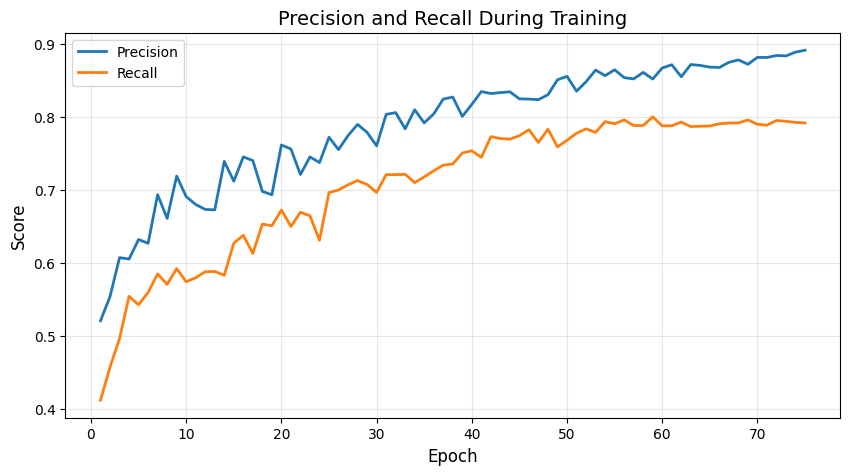

In [8]:
#Precision & Recall Curves

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    results_csv["epoch"],
    results_csv["metrics/precision(B)"],
    linewidth=2,
    label="Precision"
)

plt.plot(
    results_csv["epoch"],
    results_csv["metrics/recall(B)"],
    linewidth=2,
    label="Recall"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Precision and Recall During Training", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

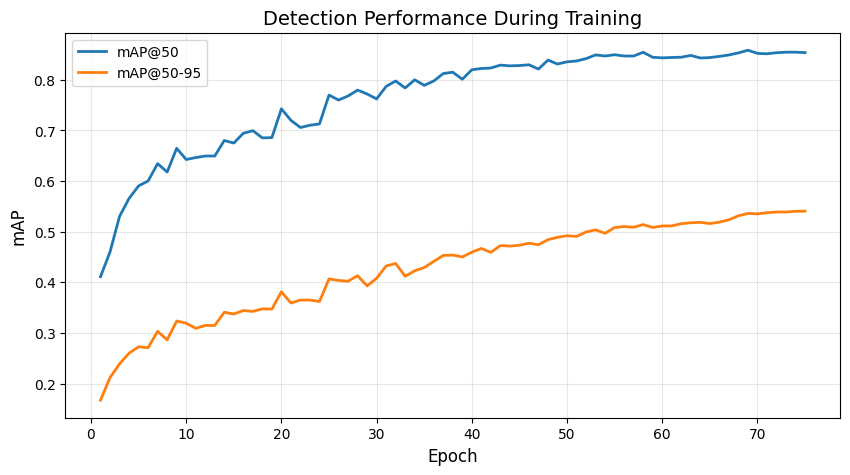

In [9]:
#MAP Curves
#mAP Curves

plt.figure(figsize=(10,5))

plt.plot(
    results_csv["epoch"],
    results_csv["metrics/mAP50(B)"],
    linewidth=2,
    label="mAP@50"
)

plt.plot(
    results_csv["epoch"],
    results_csv["metrics/mAP50-95(B)"],
    linewidth=2,
    label="mAP@50-95"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("mAP", fontsize=12)
plt.title("Detection Performance During Training", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [11]:
#Final Evaluation Metrices Table
#Final Evaluation Metrics

final_metrics = pd.DataFrame({

    "Metric":[
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50-95"
    ],

    "Final Value":[
        round(results_csv.iloc[-1]["metrics/precision(B)"],3),
        round(results_csv.iloc[-1]["metrics/recall(B)"],3),
        round(results_csv.iloc[-1]["metrics/mAP50(B)"],3),
        round(results_csv.iloc[-1]["metrics/mAP50-95(B)"],3)
    ]

})

final_metrics

,Metric,Final Value
0,Precision,0.891
1,Recall,0.792
2,mAP@50,0.854
3,mAP@50-95,0.541


In [12]:
#Best Epoch
#Best Performing Epoch

best_epoch = results_csv.loc[
    results_csv["metrics/mAP50-95(B)"].idxmax()
]

pd.DataFrame({

    "Metric":[
        "Best Epoch",
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50-95"
    ],

    "Value":[
        int(best_epoch["epoch"]),
        round(best_epoch["metrics/precision(B)"],3),
        round(best_epoch["metrics/recall(B)"],3),
        round(best_epoch["metrics/mAP50(B)"],3),
        round(best_epoch["metrics/mAP50-95(B)"],3)
    ]

})

,Metric,Value
0,Best Epoch,75.000
1,Precision,0.891
2,Recall,0.792
3,mAP@50,0.854
4,mAP@50-95,0.541


# Conclusion

The baseline RT-DETR-L model demonstrated strong performance for single-class pothole detection on the processed MWPD + RDD (India & Japan) dataset. A comprehensive evaluation of quantitative metrics, training dynamics, and qualitative predictions indicates that the detector successfully learned the pothole detection task while maintaining stable convergence throughout training.

The training and validation loss curves (GIoU, Classification, and L1 losses) consistently decreased across epochs without exhibiting significant divergence. This behavior suggests that the model converged effectively and did not suffer from severe overfitting. Validation losses closely followed the training losses, indicating good generalization to unseen data.

The detector achieved the following performance on the validation set:

- **Precision:** 89.1%
- **Recall:** 79.2%
- **mAP@50:** 85.4%
- **mAP@50-95:** 54.1%

The high precision indicates that the majority of predicted potholes correspond to actual potholes, resulting in relatively few false positive detections. The recall, while slightly lower than precision, demonstrates that most potholes present in the validation dataset were successfully detected. The gap between precision and recall suggests that the detector occasionally misses difficult potholes, particularly those that are very small, visually ambiguous, or affected by adverse environmental conditions.

Analysis of the Precision–Recall and F1-score curves further confirms that the model maintains a favorable balance between precision and recall over a wide range of confidence thresholds. This indicates that the trained detector is robust and can be deployed using different confidence thresholds depending on application requirements.

The confusion matrix reveals that the model correctly identifies the majority of pothole instances while maintaining a low false-positive rate. Since the detector focuses on a single object class, the confusion matrix primarily highlights missed detections rather than class misclassification, reinforcing the observation that recall remains the primary area for improvement.

Qualitative evaluation of validation predictions demonstrates that the model generalizes well across diverse road environments, including urban streets, highways, residential roads, and varying lighting conditions. Medium and large potholes are localized accurately with high confidence, while many small potholes are also successfully detected.

However, several challenging scenarios were observed during manual inspection:

- Very small potholes occupying only a small fraction of the image.
- Water-filled potholes with weak visual boundaries.
- Low-contrast potholes blending into the surrounding pavement.
- Potholes partially occluded by vehicles or shadows.
- Images captured under strong sunlight, glare, or motion blur.

These cases occasionally resulted in lower confidence scores or missed detections, indicating opportunities for further optimization.

Overall, the baseline RT-DETR-L model establishes a strong foundation for the proposed AI-based road hazard detection system. The achieved performance demonstrates that transformer-based object detectors are well suited for pothole detection in real-world driving scenarios while providing accurate localization and reliable detection performance.

The findings from this evaluation also provide clear directions for future experimentation. Subsequent optimization studies will investigate the effects of stronger data augmentation, higher input image resolutions, alternative learning-rate schedules, longer training durations, and additional hyperparameter tuning to further improve recall and localization accuracy, particularly for small and visually challenging potholes.

In summary, the baseline model provides a reliable benchmark against which all future experiments will be compared, enabling systematic performance improvements through evidence-based optimization rather than empirical trial and error.